## Multi-Head Latent Attention (MLA) — The DeepSeek Revolution

### The Flaw in GQA (The Hard Floor)
GQA is great, but it has a hard limit. You cannot shrink the number of Filing Cabinets (KV Heads) past 1. If you drop it to 1, you get Multi-Query Attention (MQA), and the AI becomes stupid because 32 Executives are fighting over 1 exact same piece of paper.

DeepSeek realized the problem wasn't the number of filing cabinets. The problem was that we were storing **uncompressed paper**.

### The Analogy: The Zip File

| Approach | Strategy |
|----------|----------|
| **MHA** | 32 Executives print 32 heavy reports and put them in 32 cabinets. |
| **GQA** | 8 Secretaries print 8 heavy reports, and 32 Executives share them. |
| **MLA (DeepSeek)** | The CEO takes the entire company's knowledge, **zips it into a single, tiny USB drive**, and puts the USB drive in the drawer. |

When the 32 Executives need to ask a question, they plug the tiny USB drive into a computer, unzip the files on the fly, read what they need, and then immediately delete the unzipped files.

> **The Golden Rule of MLA:** We do not cache Keys. We do not cache Values. We ONLY cache the tiny zipped USB drive.

# working

### Part 1: The Bottleneck (Compression & Decompression)

Let's imagine a microscopic AI.
* Our full word embedding ($d$) is **4 numbers**.
* We want to compress our Key Cache into a tiny **Latent Vector** ($c$) of just **2 numbers**.

---

#### 1. The Down-Projection (Zipping it up)

The model learns a Down-Projection matrix, $W_{DK}$. Its job is to map 4 dimensions down to 2.

Let's say our word "Apple" comes in as `[10, 20, 30, 40]`.
It hits the $W_{DK}$ matrix (a $4 \times 2$ grid of learned weights).
The math multiplies them together and spits out our compressed **Latent Vector** ($C$):

$$C = [105, 42]$$

This is what goes into the KV Cache. Instead of storing 4 numbers, we only store 2. For a 100,000 token context window, you just **cut your VRAM bill in half**.

---

#### 2. The Up-Projection (Unzipping it)

Now it's time to generate text. The model needs the full 4-number Key to calculate the attention score.

It pulls $C$ (`[105, 42]`) out of the cache and passes it through the **Up-Projection** matrix, $W_{UK}$ (a $2 \times 4$ grid of weights).
It inflates the vector back to 4 dimensions to create our Key ($K$):

$$K = [11, 19, 32, 38]$$

Notice something? The recovered $K$ `[11, 19, 32, 38]` is **not** exactly the original `[10, 20, 30, 40]`.

This is **lossy compression**. But because the neural network learned the matrices during training, it learned to keep the most mathematically important concepts (like grammar and tone) and throw away the useless noise. It is a highly optimized, imperfect recovery.

# Genius of MLA
The Master Matrix Trick (The Genius of MLA)Part 1 is great for saving VRAM, but it creates a massive speed problem.If you have 100,000 tokens in your cache, you have to run that Up-Projection math (C $\times$ $W_{UK}$) 100,000 times for every single word you generate. Your GPU will choke.Here is how DeepSeek bypassed the decompression step entirely using high school algebra.Let's look at the standard Attention Score formula:$$\text{Score} = Q \cdot K^T$$But wait! We just established that $K$ is actually the Latent Vector ($C$) multiplied by the Up-Projection matrix ($W_{UK}$).So we can rewrite the formula:$$\text{Score} = Q \cdot (C \cdot W_{UK})^T$$Using the rules of matrix transposition, $(A \cdot B)^T = B^T \cdot A^T$. Let's apply that:$$\text{Score} = Q \cdot (W_{UK}^T \cdot C^T)$$Here is the masterstroke. Matrix multiplication is associative. $(A \cdot B) \cdot C = A \cdot (B \cdot C)$.DeepSeek engineers shifted the parentheses to the left:$$\text{Score} = (Q \cdot W_{UK}^T) \cdot C^T$$Why is this a trillion-dollar equation?Look at the left side of that equation: $(Q \cdot W_{UK}^T)$.$Q$ is the current token we are generating. There is only ONE of them.$W_{UK}$ is a static weight matrix.Instead of unzipping the 100,000 tiny $C$ vectors in the cache... we just mutate the 1 Query vector.We take our single $Q$ and multiply it by $W_{UK}^T$. We will call this mutated query $Q'$.Now, our formula is simply:$$\text{Score} = Q' \cdot C^T$$The physical result in the GPU:We never decompress the cache. We leave the 100,000 tokens sitting in VRAM as tiny 2-number zipped files.Instead, we equip our single Query with a "decoder ring" ($Q'$). That mutated Query can now directly read the zipped files and calculate the exact same mathematical score as if we had decompressed everything.Standard Method: 100,000 heavy matrix multiplications (Unzipping the cache).DeepSeek Method: 1 tiny matrix multiplication (Mutating the Query), followed by a basic dot product.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class StructuredMLATrace(nn.Module):
    def __init__(self, d_model=16, num_heads=2, latent_dim=4):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.latent_dim = latent_dim
        
        # --- THE ML LAYERS ---
        self.w_q = nn.Linear(d_model, d_model, bias=False)  # Q Blender
        self.w_dk = nn.Linear(d_model, latent_dim, bias=False) # Down-Projector (Zip)
        self.w_uk = nn.Linear(latent_dim, d_model, bias=False) # Up-Projector (Unzip)
        
        # We will focus purely on Q * K^T score absorption trick for this trace.
        # DeepSeek also compresses V, but score calculation is the algebraic genius part.
        
        self.print_header()

    def print_header(self):
        print("="*100)
        print(f"{'MULTI-HEAD LATENT ATTENTION (MLA) TENSOR JOURNEY':^100}")
        print("="*100)
        print(f"Dimensions: d_model={self.d_model}, Heads={self.num_heads}, "
              f"Head_Dim={self.head_dim}, Latent_Cache_Dim={self.latent_dim}")
        print("-" * 100)
        print(f"{'STEP':<10} | {'EQUATION':<35} | {'CODE LOGIC':<20} | {'SHAPE':<15}")
        print("-" * 100)

    def print_step(self, step, equation, logic, tensor):
        print(f"{step:<10} | {equation:<35} | {logic:<20} | {str(list(tensor.shape)):<15}")

    def forward(self, x):
        B, T, C = x.shape
        self.print_step("0. Input", "x", "Raw Sentence", x)

        # ==============================================================================
        # PHASE 1: STANDARD Q GENERATION
        # ==============================================================================
        q_raw = self.w_q(x)
        self.print_step("1a. Q Proj", "Q_raw = x @ W_q", "Full Q Blender", q_raw)
        
        q = q_raw.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        self.print_step("1b. Q Split", "Q = view(B,H,T,d_h)", "Slice into Heads", q)
        print("."*100)

        # ==============================================================================
        # PHASE 2: KV COMPRESSION (Caching C, not K or V)
        # ==============================================================================
        c = self.w_dk(x)
        self.print_step("2a. Compress", "C = x @ W_dk", "Down-Projection (Zip)", c)
        
        # THIS IS WHAT GOES INTO CACHE. Note T dimension is stored.
        print(f"\n[!!! CACHE NOTE !!!] Storing Latent Vector C instead of Full K. ")
        print(f"Size stored in VRAM: {c.nelement()} numbers (vs MHA standard {x.nelement()*2} numbers)")
        print("."*100)

        # ==============================================================================
        # PHASE 3: SCORING (The standard slow way for comparison)
        # ==============================================================================
        print(f"\n--- THE STANDARD (SLOW) APPROACH: SCORE = Q * (C * W_uk)^T ---")
        
        # Decompress the WHOLE cache to match Q shape
        k_full_raw = self.w_uk(c)
        self.print_step("3a. Unzip K", "K_full = C @ W_uk", "Up-Projection (Slow)", k_full_raw)
        
        k_full = k_full_raw.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        self.print_step("3b. Split K", "K_full = view(B,H,T,d_h)", "Align shapes", k_full)
        
        scores_std = torch.matmul(q, k_full.transpose(-2, -1))
        self.print_step("3c. Score", "Score = Q @ K_full^T", "Matmul (N^2 ops)", scores_std)
        print("."*100)

        # ==============================================================================
        # PHASE 4: SCORING (The DeepSeek Fast way - Matrix Absorption)
        # ==============================================================================
        print(f"\n--- THE DEEPSEEK (FAST) APPROACH: SCORE = (Q * W_uk^T) * C^T ---")
        
        # Prepare the decoder matrix (absorb it into Q)
        # W_uk shape is (latent, model). Transpose is (model, latent).
        w_uk_t = self.w_uk.weight.t() # PyTorch linear weights are stored transposed already (d_out, d_in)
        
        # Reshape W_uk^T to match head structure so Q can multiply it
        # (latent_dim, model_dim) -> (latent_dim, num_heads, head_dim)
        w_dec = w_uk_t.view(self.latent_dim, self.num_heads, self.head_dim)
        # (num_heads, head_dim, latent_dim) for easier parallel matmul with Q
        w_dec = w_dec.permute(1, 2, 0)
        
        # Mutate Q: (B, H, T, d_h) @ (H, d_h, dc) -> (B, H, T, dc)
        # Q absorbs the up-projection logic. It now acts in latent space.
        q_absorbed = torch.matmul(q, w_dec)
        self.print_step("4a. Mutate Q", "Q' = Q @ W_uk^T", "Absorb Unzip Matrix", q_absorbed)
        
        # Prepare tiny C for direct multiplication
        # (B, T, dc) -> (B, 1, dc, T) for broadcasting across H heads
        c_t = c.unsqueeze(1).transpose(-2, -1)
        
        # Fast Score: (B, H, T, dc) @ (B, 1, dc, T) -> (B, H, T, T)
        scores_fast = torch.matmul(q_absorbed, c_t)
        self.print_step("4b. Fast Score", "Score = Q' @ C^T", "Matmul (Tiny ops)", scores_fast)
        
        # ==============================================================================
        # VERIFICATION
        # ==============================================================================
        print("="*100)
        diff = torch.abs(scores_std - scores_fast).max()
        if diff < 1e-4:
            print(f"✅ VERIFIED: Standard and Fast algebra match! Max diff: {diff:.6f}")
            print(f"Genius: We calculated Scores without ever 'unzipping' the Key cache.")
        else:
            print(f"❌ ERROR: Math does not match! Diff: {diff:.6f}")
        print("="*100)

if __name__ == "__main__":
    torch.manual_seed(42)
    dummy_input = torch.randn(1, 4, 16) # B=1, T=4, d=16
    mla = StructuredMLATrace()
    mla(dummy_input)

                          MULTI-HEAD LATENT ATTENTION (MLA) TENSOR JOURNEY                          
Dimensions: d_model=16, Heads=2, Head_Dim=8, Latent_Cache_Dim=4
----------------------------------------------------------------------------------------------------
STEP       | EQUATION                            | CODE LOGIC           | SHAPE          
----------------------------------------------------------------------------------------------------
0. Input   | x                                   | Raw Sentence         | [1, 4, 16]     
1a. Q Proj | Q_raw = x @ W_q                     | Full Q Blender       | [1, 4, 16]     
1b. Q Split | Q = view(B,H,T,d_h)                 | Slice into Heads     | [1, 2, 4, 8]   
....................................................................................................
2a. Compress | C = x @ W_dk                        | Down-Projection (Zip) | [1, 4, 4]      

[!!! CACHE NOTE !!!] Storing Latent Vector C instead of Full K. 
Size stored 

Calculating memory footprints and generating plots...
✅ Plots generated successfully as 'mla_memory_savings_comparison.png'


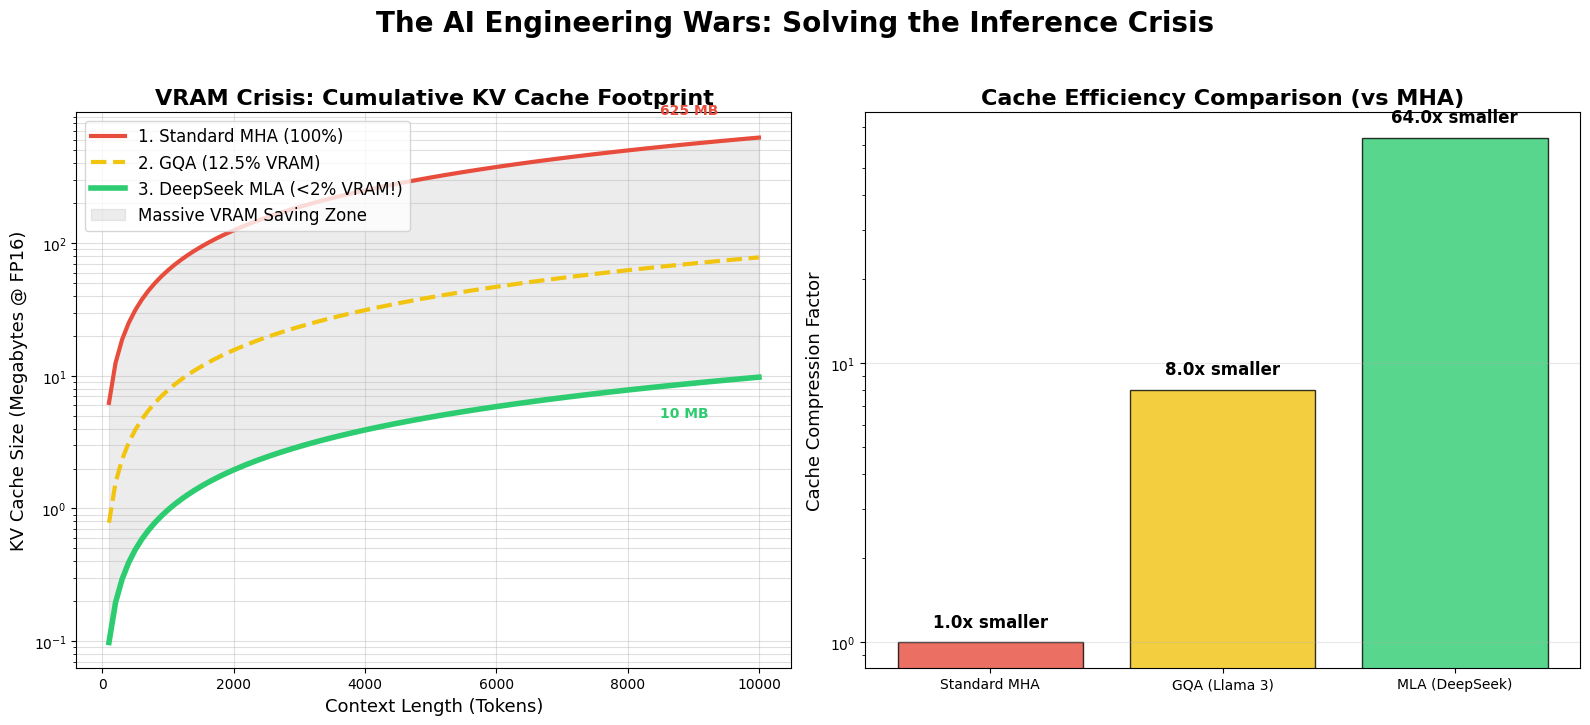

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def generate_mla_plots():
    print("Calculating memory footprints and generating plots...")
    # Simulation parameters (mimicking large scale)
    seq_length = np.arange(100, 10001, 100) # Up to 10k tokens context
    batch_size = 1
    d_model = 5120  # Llama 3 / DeepSeek scale
    num_heads = 128
    head_dim = 128
    
    # 1. Standard MHA (Stores 128 full Key heads + 128 full Value heads per token)
    # Stored = H * dh * 2 (K and V)
    mha_elements_per_token = num_heads * head_dim * 2
    
    # 2. GQA (Llama 3 70B scale - reduces KV heads by 8x)
    num_kv_heads_gqa = num_heads // 8
    gqa_elements_per_token = num_kv_heads_gqa * head_dim * 2
    
    # 3. MLA (DeepSeek-V2 Unified unified latent for KV)
    # They don't store Heads * D_h. They store one single Latent Vector C.
    # DeepSeek V2 uses dc = 512.
    mla_dc = 512
    # In practice they split RoPE and unified, but dc=512 is the core stored part.
    # Total stored per token = dc
    mla_elements_per_token = mla_dc 
    
    # Calculate MB (assuming float16 / 2 bytes per number for large models)
    bytes_per_number = 2
    
    mha_mem_mb = (mha_elements_per_token * batch_size * seq_length * bytes_per_number) / (1024 * 1024)
    gqa_mem_mb = (gqa_elements_per_token * batch_size * seq_length * bytes_per_number) / (1024 * 1024)
    mla_mem_mb = (mla_elements_per_token * batch_size * seq_length * bytes_per_number) / (1024 * 1024)

    # Calculate Compression Ratios vs MHA
    gqa_compression = mha_elements_per_token / gqa_elements_per_token
    mla_compression = mha_elements_per_token / mla_elements_per_token

    # --- PLOTTING ---
    fig = plt.figure(figsize=(16, 7))
    
    # Subplot 1: Cumulative KV Cache Size
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(seq_length, mha_mem_mb, label=f'1. Standard MHA (100%)', color='#e74c3c', linewidth=3)
    ax1.plot(seq_length, gqa_mem_mb, label=f'2. GQA (12.5% VRAM)', color='#f1c40f', linewidth=3, linestyle='--')
    ax1.plot(seq_length, mla_mem_mb, label=f'3. DeepSeek MLA (<2% VRAM!)', color='#2ecc71', linewidth=4)
    
    ax1.fill_between(seq_length, mha_mem_mb, mla_mem_mb, color='gray', alpha=0.15, label='Massive VRAM Saving Zone')
    
    ax1.set_title("VRAM Crisis: Cumulative KV Cache Footprint", fontsize=16, fontweight='bold')
    ax1.set_xlabel("Context Length (Tokens)", fontsize=13)
    ax1.set_ylabel("KV Cache Size (Megabytes @ FP16)", fontsize=13)
    ax1.set_yscale('log') # Log scale emphasizes the difference
    ax1.legend(fontsize=12, loc='upper left')
    ax1.grid(True, which="both", alpha=0.4)
    
    # Highlighting 10k token VRAM cost
    mha_10k = mha_mem_mb[-1]
    mla_10k = mla_mem_mb[-1]
    ax1.annotate(f'{mha_10k:.0f} MB', xy=(10000, mha_10k), xytext=(8500, mha_10k*1.5), color='#e74c3c', fontweight='bold')
    ax1.annotate(f'{mla_10k:.0f} MB', xy=(10000, mla_10k), xytext=(8500, mla_10k/2), color='#2ecc71', fontweight='bold')


    # Subplot 2: Compression Ratio (Bar Chart)
    ax2 = plt.subplot(1, 2, 2)
    methods = ['Standard MHA', 'GQA (Llama 3)', 'MLA (DeepSeek)']
    ratios = [1.0, gqa_compression, mla_compression]
    colors = ['#e74c3c', '#f1c40f', '#2ecc71']
    
    bars = ax2.bar(methods, ratios, color=colors, edgecolor='black', alpha=0.8)
    
    ax2.set_title("Cache Efficiency Comparison (vs MHA)", fontsize=16, fontweight='bold')
    ax2.set_ylabel("Cache Compression Factor", fontsize=13)
    ax2.set_yscale('log') # Log scale because MLA difference is so huge
    ax2.grid(axis='y', alpha=0.3)
    
    # Add labels on top of bars
    for bar, ratio in zip(bars, ratios):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, height * 1.1,
                 f'{ratio:.1f}x smaller', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.suptitle("The AI Engineering Wars: Solving the Inference Crisis", fontsize=20, y=1.03, fontweight='bold')
    plt.tight_layout()

if __name__ == "__main__":
    generate_mla_plots()